# LING 498 Hackathon - Register shift: Zipf by genre
**Question: Does Zipf look different across genres (e.g., news vs fiction)?**

In [39]:
import re
from nltk.corpus import brown
from nltk import FreqDist

# if NLTK Brown corpus isn't already downloaded in runtime, uncomment:
# nltk.download('brown')

In [40]:
# Helpter functions
def zipf_prep(items, min_count=1):
    fd = FreqDist(items)
    # drop ultra-rare if desired
    items2 = [(k,v) for k,v in fd.items() if v >= min_count]
    items2.sort(key=lambda kv: kv[1], reverse=True)
    return items2  # list of (item, count) sorted

def zipf_quick_report(items, title="", topn=15):
    ranked = zipf_prep(items)
    print(f"\n=== {title} ===")
    print(f"Types: {len(ranked)} | Tokens: {sum(c for _,c in ranked)}")
    print("Top items:")
    for i,(k,v) in enumerate(ranked[:topn], start=1):
        print(f"{i:>2}. {str(k)[:40]:<40} {v}")
    # simple “Zipf-ness” sanity check (no regression): f1 ~ 2*f2 ~ 3*f3?
    if len(ranked) >= 5:
        f1,f2,f3,f4,f5 = [ranked[i][1] for i in range(5)]
        print("\nHeuristic ratios (closer to 1 is more Zipf-like):")
        print(" f1/(2*f2) =", round(f1/(2*f2), 3))
        print(" f1/(3*f3) =", round(f1/(3*f3), 3))
        print(" f1/(4*f4) =", round(f1/(4*f4), 3))
        print(" f1/(5*f5) =", round(f1/(5*f5), 3))
    return ranked

# Optional plotting cell (instructor can pre-enable if matplotlib is available)
def zipf_plot(ranked, n=1000, title="Top 1000 _______"):
    import matplotlib.pyplot as plt
    ranks = list(range(1, min(n, len(ranked))+1))
    freqs = [ranked[i-1][1] for i in ranks]
    plt.figure(figsize=(6,4))
    plt.loglog(ranks, freqs, marker='.')
    plt.xlabel("rank (log)")
    plt.ylabel("frequency (log)")
    plt.title(title)
    plt.tight_layout()
    plt.show()

In [ ]:
# Picking 2 categories from the Brown corpus for analysis

# News 
news_tokens = [
    token.lower()
    for token in brown.words(categories="news")
    if not re.fullmatch(r"\W+", token)
]

# Fiction 
fiction_tokens = [
    token.lower()
    for token in brown.words(categories="fiction")
    if not re.fullmatch(r"\W+", token)
]

# **the version below is simplified without cleaning**
# news_tokens = brown.words(categories="news")
# fiction_tokens = brown.words(categories="fiction")


=== News ===
Types: 13099 | Tokens: 88592
Top items:
 1. the                                      6386
 2. of                                       2861
 3. and                                      2186
 4. to                                       2144
 5. a                                        2130
 6. in                                       2020
 7. for                                      969
 8. that                                     829
 9. is                                       733
10. was                                      717

Heuristic ratios (closer to 1 is more Zipf-like):
 f1/(2*f2) = 1.116
 f1/(3*f3) = 0.974
 f1/(4*f4) = 0.745
 f1/(5*f5) = 0.6


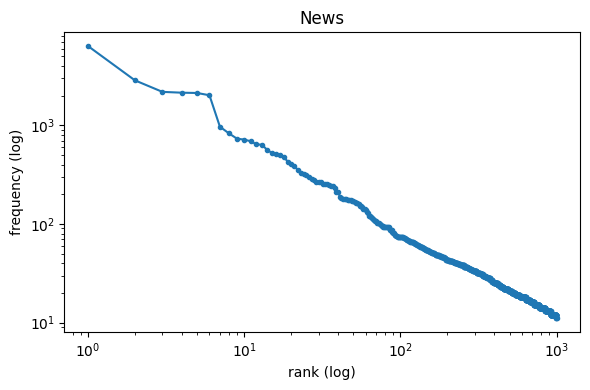

In [42]:
# Zipf analysis for 'news' category
news_ranked = zipf_quick_report(news_tokens,title="News",topn=10)
zipf_plot(news_ranked,title="News")


=== Fiction ===
Types: 8667 | Tokens: 58317
Top items:
 1. the                                      3792
 2. and                                      1770
 3. to                                       1508
 4. of                                       1423
 5. a                                        1339
 6. he                                       1308
 7. was                                      1091
 8. in                                       971
 9. his                                      795
10. had                                      728

Heuristic ratios (closer to 1 is more Zipf-like):
 f1/(2*f2) = 1.071
 f1/(3*f3) = 0.838
 f1/(4*f4) = 0.666
 f1/(5*f5) = 0.566


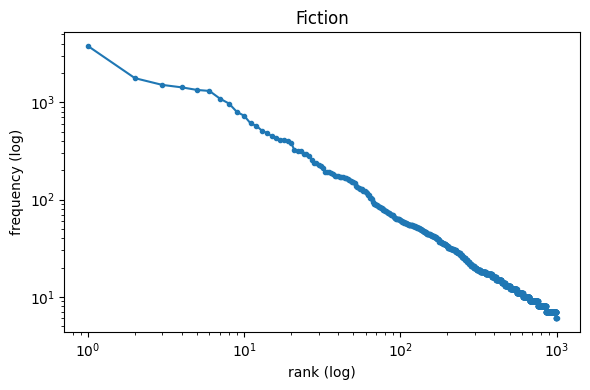

In [43]:
# Zipf analysis for 'fiction' category
fiction_ranked = zipf_quick_report(fiction_tokens,title="Fiction",topn=10)
zipf_plot(fiction_ranked,title="Fiction")

In [45]:
# Comparing Top 10 from 'News' and 'Fiction'
print(f"{'News':<20} {'Fiction':<20}")
print("-" * 40)

for (news_tokens, _), (fiction_tokens, _) in zip(news_ranked[:10], fiction_ranked[:10]):
    print(f"{news_tokens:<20} {fiction_tokens:<20}")

News                 Fiction             
----------------------------------------
the                  the                 
of                   and                 
and                  to                  
to                   of                  
a                    a                   
in                   he                  
for                  was                 
that                 in                  
is                   his                 
was                  had                 


## Interpretation 

Both genres are dominated by common function words such as the, of, and and, which are frequent in English regardless of genre. However, fiction contains more pronouns (e.g., he, his) since fiction narratives focus on characters and dialogue whereas news contains more prepositions and function words to convey information.

Moreover, both genres have heuristic ratios close to 1 for the highest-ranked words, indicating that they both follow Zipf's Law. Small differences suggest that the frequency distribution varies slightly between registers, but both exhibit the expected Zipf-like pattern.